# Exploratory Data Analysis — Online Shoppers Intention

## 0. Hypotheses

1. Более длительное взаимодействие с product-related страницами связано с большей вероятностью покупки.
2. Из-за дисбаланса классов Accuracy может быть малоинформативной; при оценке моделей важны Recall, Precision, F1 и PR-AUC.
3. Decision Tree может описывать нелинейные поведенческие паттерны лучше линейного baseline, но это проверяется только на валидации.
4. `PageValues` содержит сильный сигнал для `Revenue`; baseline только на `PageValues` позволит оценить, насколько много информации даёт этот признак сам по себе.
5. `class_weight='balanced'` в Logistic Regression изменит компромисс Precision/Recall; направление и величина эффекта проверяются экспериментально.

In [20]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Data Loading & Initial Inspection

Ноутбук ожидает `online_shoppers_intention.csv` рядом с собой. При необходимости путь можно поменять в `DATA_PATH`.

In [21]:
DATA_PATH = 'online_shoppers_intention.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'Файл {DATA_PATH!r} не найден.'
    )

df = pd.read_csv(DATA_PATH)
print(f'Размер датасета: {df.shape}')
display(df.head())
display(df.info())

Размер датасета: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.000,0,0.000,2,64.000,0.000,0.100,0.000,0.000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.000,0,0.000,2,2.667,0.050,0.140,0.000,0.000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.000,0,0.000,10,627.500,0.020,0.050,0.000,0.000,Feb,3,3,1,4,Returning_Visitor,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

None

In [22]:
print('Типы данных:')
display(df.dtypes.to_frame('dtype'))

print('Количество пропусков:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing'))

print(f'Полных дубликатов: {df.duplicated().sum()}')

Типы данных:


,dtype
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


Количество пропусков:


,missing
Administrative,0
Administrative_Duration,0
Weekend,0
VisitorType,0
TrafficType,0
Region,0
Browser,0
OperatingSystems,0
Month,0
SpecialDay,0


Полных дубликатов: 125


### Описание полей

`Revenue` — целевая переменная на уровне сессии. Это довольно важно помнить. Поэтому в выводах ниже используем «сессия», а не «пользователь»: отдельного идентификатора пользователя в датасете нет.

Числовые поля условно разделяем на счётчики, длительности и поведенческие метрики. `Browser`, `OperatingSystems`, `Region` и `TrafficType` чисто технически представлены числами, но по смыслу явно являются категориальными кодами.

In [23]:
continuous_features = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

count_features = [
    'Administrative', 'Informational', 'ProductRelated',
    'OperatingSystems', 'Browser', 'Region', 'TrafficType'
]

categorical_features = [
    'Month', 'VisitorType', 'Weekend',
    'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'SpecialDay'
]

print('Уникальные значения Revenue:')
display(df['Revenue'].value_counts(dropna=False).to_frame('count'))

Уникальные значения Revenue:


,count
Revenue,
False,10422
True,1908


## 2. Target Balance

Это одна из первых вещей, которую важно проверить до обсуждения качества моделей.

,count,share_%
Revenue,,
False,10422,84.526
True,1908,15.474


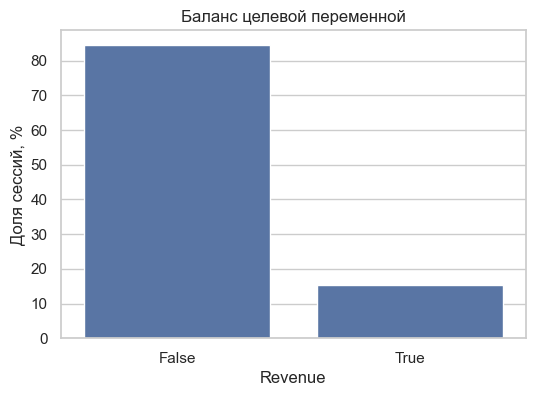

In [24]:
target_counts = df['Revenue'].value_counts().sort_index()
target_share = df['Revenue'].value_counts(normalize=True).sort_index().mul(100)

target_summary = pd.DataFrame({
    'count': target_counts,
    'share_%': target_share
})
display(target_summary)

plt.figure(figsize=(6, 4))
sns.barplot(x=target_summary.index.astype(str), y=target_summary['share_%'], errorbar=None)
plt.xlabel('Revenue')
plt.ylabel('Доля сессий, %')
plt.title('Баланс целевой переменной')
plt.show()

Класс `Revenue=True` заметно реже `Revenue=False`, поэтому accuracy сама по себе может создавать слишком оптимистичное впечатление о модели. Но это оставим на попозже. На этапе ML обязательно сравним её с Recall, Precision, F1 и PR-AUC.

## 3. Data Cleaning: Missing Values & Duplicates

Полные дубликаты лучше не удалять автоматически. Так как ID сессии нельзя установить, то и невозможно узнать, являются ли одинаковые строки повторной записью или независимыми сессиями с одинаковыми характеристиками.

In [25]:
missing_total = int(df.isna().sum().sum())
duplicate_total = int(df.duplicated().sum())

print(f'Всего пропусков: {missing_total}')
print(f'Полных дубликатов: {duplicate_total}')

if duplicate_total:
    display(df[df.duplicated(keep=False)].head(10))

Всего пропусков: 0
Полных дубликатов: 125


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,3,2,3,3,Returning_Visitor,False,False
252,0,0.000,0,0.000,2,0.000,0.200,0.200,0.000,0.000,Mar,1,1,1,1,Returning_Visitor,False,False
286,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Mar,2,2,1,1,Returning_Visitor,False,False
293,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Mar,1,1,1,1,Returning_Visitor,True,False
298,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Mar,1,1,8,1,Returning_Visitor,False,False
330,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Mar,3,2,3,1,Returning_Visitor,False,False


Решение: сохраняем дубликаты и явно фиксируем это как ограничение данных. Это предпочтительнее, чем автоматически удалять записи и менять распределение целевой переменной без надёжного основания.

## 4. Univariate Analysis

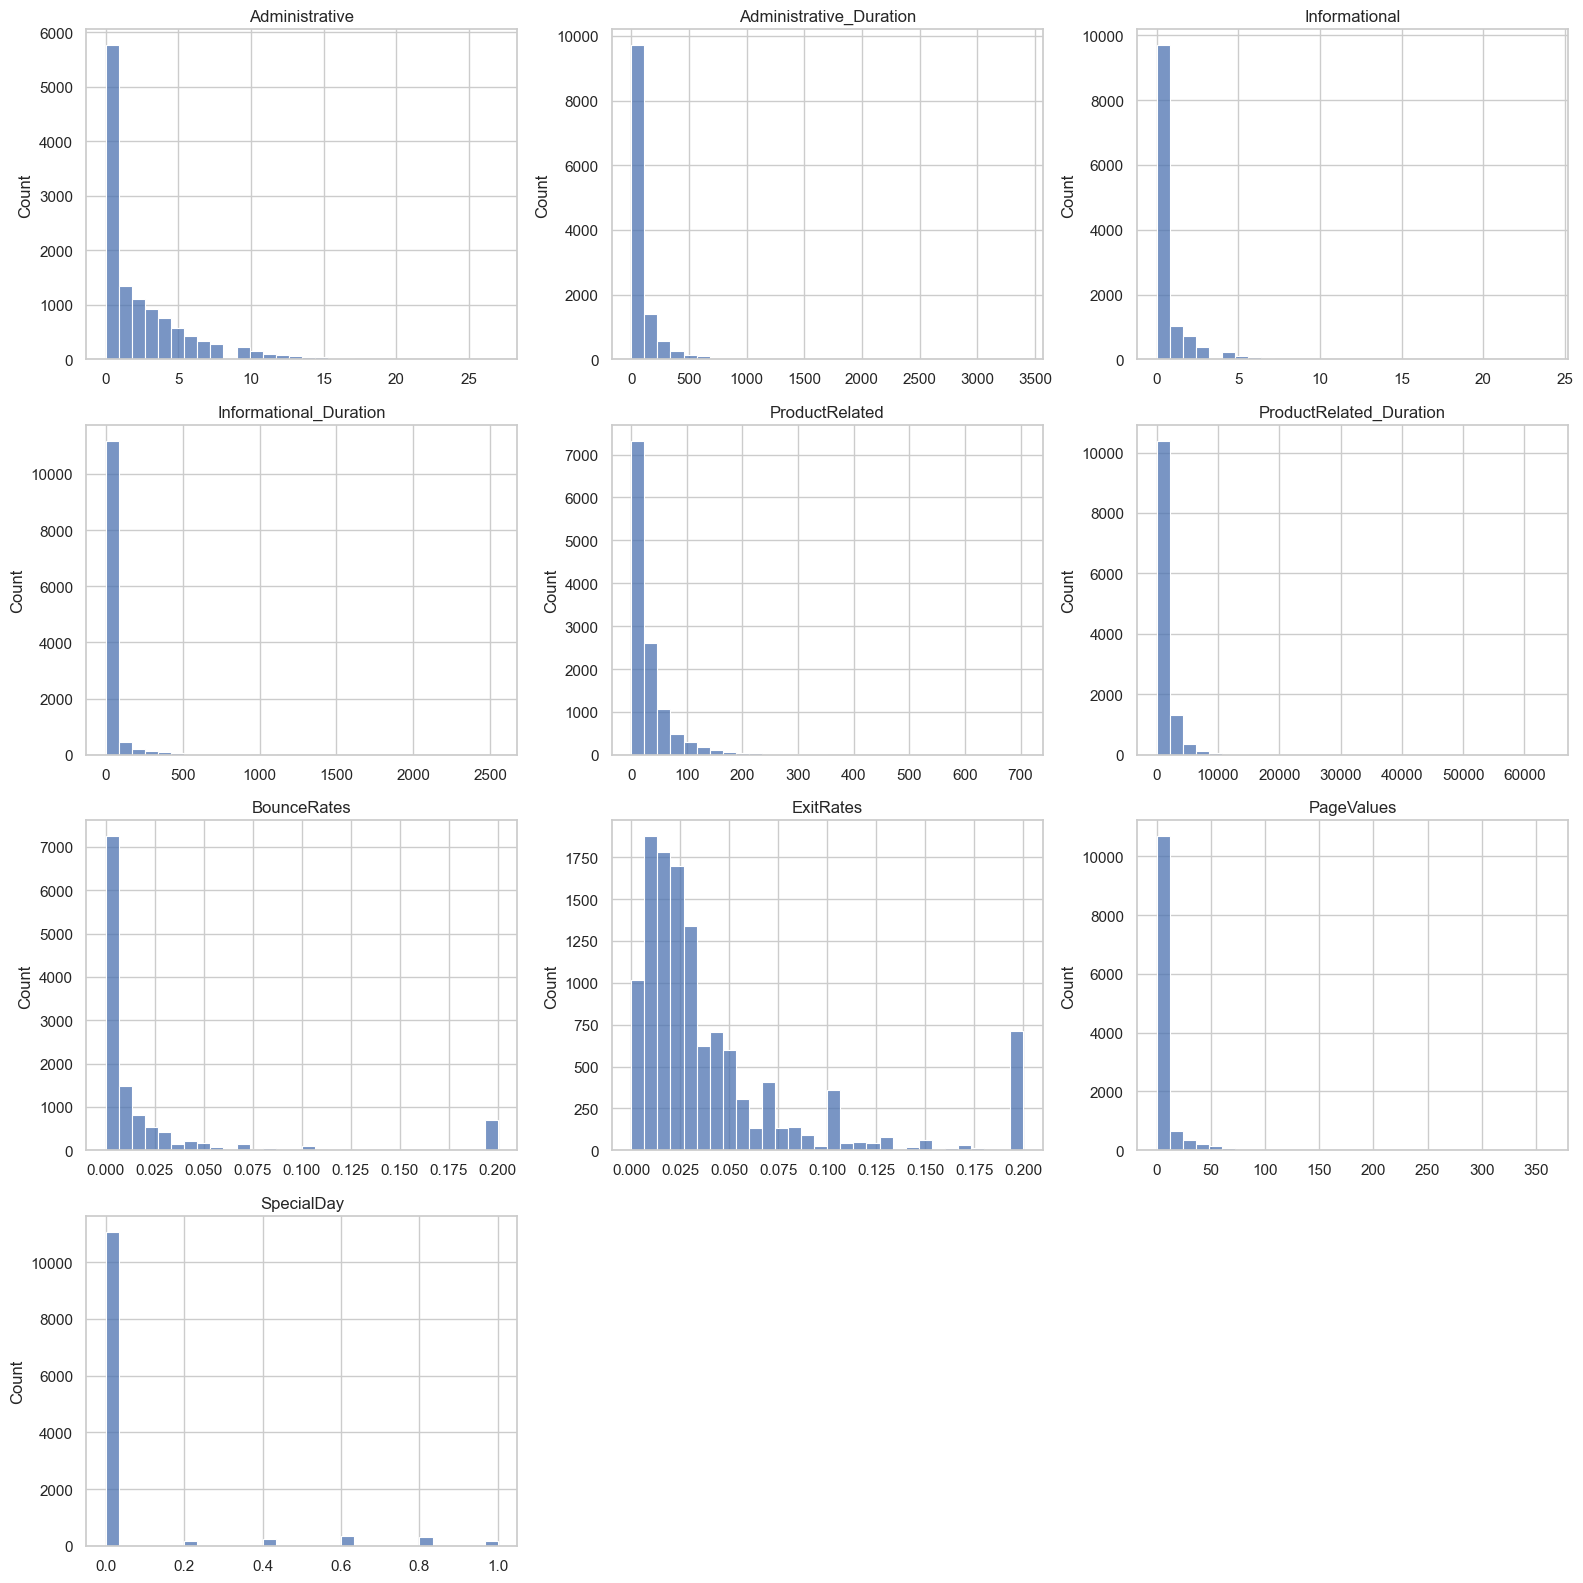

In [26]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for ax, feature in zip(axes, continuous_features):
    sns.histplot(data=df, x=feature, bins=30, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')

for ax in axes[len(continuous_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Что видно по распределениям

- Многие признаки сильно скошены вправо: основная масса сессий имеет небольшие значения, а небольшая часть — очень большие.
- Это не означает автоматически, что «линейная модель будет хуже». Выбор модели проверяется экспериментально; для линейных моделей разумно использовать масштабирование и при необходимости преобразования признаков.
- Экстремальные значения стоит учитывать при визуализации и выборе scaler, но не удалять только потому, что они выглядят необычно.

### `PageValues` — отдельный случай

У него большая масса нулей, поэтому полезно разделить сессии на `PageValues == 0` и `PageValues > 0`, а не пытаться интерпретировать один boxplot.

In [27]:
page_values_summary = (
    df.assign(PageValues_positive=df['PageValues'].gt(0))
      .groupby('PageValues_positive')['Revenue']
      .agg(['count', 'mean'])
      .rename(columns={'mean': 'conversion_rate'})
)
page_values_summary['share_%'] = page_values_summary['count'] / len(df) * 100

display(page_values_summary)

,count,conversion_rate,share_%
PageValues_positive,,,
False,9600,0.039,77.859
True,2730,0.563,22.141


Здесь мы пока говорим только о связи: разница в conversion rate между группами `PageValues == 0` и `PageValues > 0` не доказывает причинный эффект `PageValues`.

## 5. Correlation & Feature Relationships

Pearson correlation полезна как быстрый индикатор линейной зависимости, но высокая корреляция не равна причинности и не означает одинаковой степени проблемы для всех моделей.

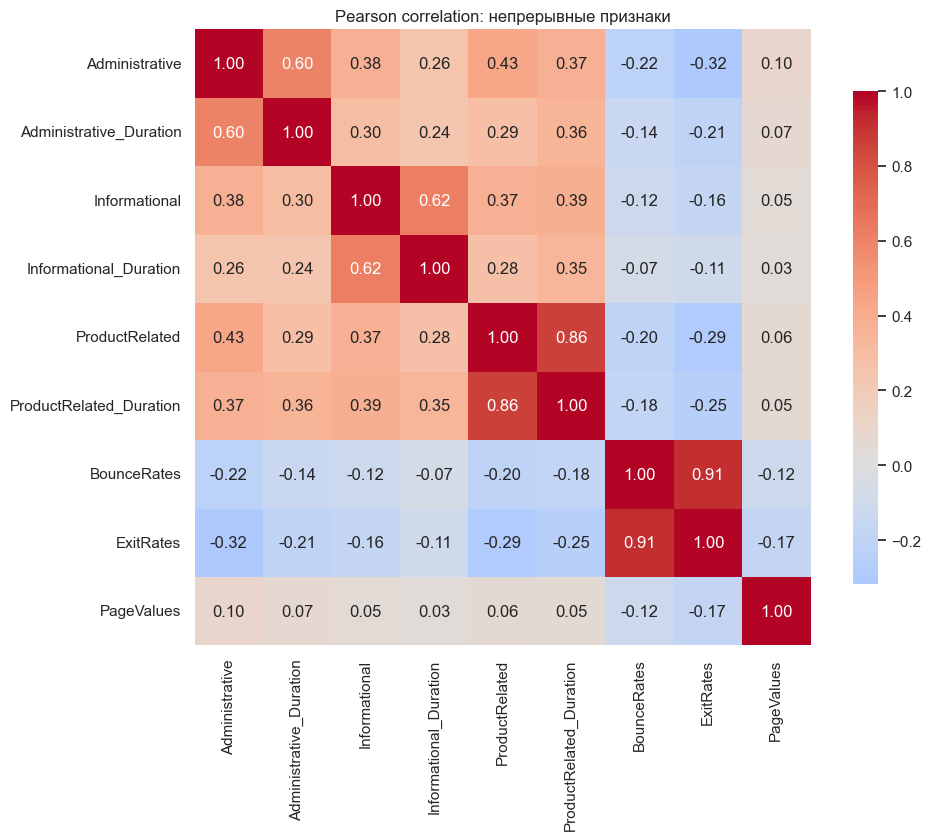

In [28]:
corr_features = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues'
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Pearson correlation: непрерывные признаки')
plt.show()

### `ProductRelated` и `ProductRelated_Duration`

Оба признака естественно связаны: больше просмотренных product-related страниц обычно означает и большее суммарное время. Но они описывают разные аспекты поведения — масштаб просмотра и суммарную длительность.

Добавим среднюю длительность одной просмотренной product-related страницы — `Avg_Product_Related`. Важно не использовать `+1` в знаменателе: это искусственно занижает показатель для всех ненулевых наблюдений. Для `ProductRelated == 0` задаём значение `0` явно.

In [29]:
df_processed = df.copy()

df_processed['Avg_Product_Duration'] = np.where(
    df_processed['ProductRelated'] > 0,
    df_processed['ProductRelated_Duration'] / df_processed['ProductRelated'],
    0.0
)

display(
    df_processed[['ProductRelated', 'ProductRelated_Duration', 'Avg_Product_Duration']]
    .describe()
)

,ProductRelated,ProductRelated_Duration,Avg_Product_Duration
count,"12,330.000","12,330.000","12,330.000"
mean,31.731,"1,194.746",37.634
std,44.476,"1,913.669",44.768
min,0.000,0.000,0.000
25%,7.000,184.137,17.613
50%,18.000,598.937,28.878
75%,38.000,"1,464.157",45.084
max,705.000,"63,973.522","1,411.000"


### Как интерпретировать мультиколлинеарность

- Для линейной модели высокая корреляция может сделать коэффициенты менее стабильными и усложнить интерпретацию.
- Для Decision Tree высокая корреляция сама по себе обычно менее критична.
- L2-регуляризация стабилизирует оценивание коэффициентов, но не удаляет мультиколлинеарность и не делает коррелирующие признаки независимыми.

Поэтому пока не выбрасываем `ProductRelated` и `ProductRelated_Duration` автоматически. На этапе моделирования можно сравнить полную и сокращённую спецификации.

### `BounceRates` и `ExitRates`

Корреляция между ними высокая. Это повод проверить дублирование информации, но не повод утверждать, что один из признаков «шум».

Для baseline ML оставим `ExitRates` и исключим `BounceRates` как более простой способ уменьшить дублирование. Это **модельное решение**, а не утверждение о том, что `BounceRates` бесполезен во всех задачах.

## 6. Categorical Features & Conversion Rate

Для категориальных переменных важно показывать не только размер групп, но и conversion rate. При этом редкие категории следует интерпретировать осторожно: высокая или низкая конверсия у нескольких наблюдений может быть нестабильной оценкой.

In [ ]:
for feature in ['Month', 'VisitorType', 'Browser', 'OperatingSystems', 'Region', 'TrafficType', 'SpecialDay', 'Weekend']:
    summary = (
        df.groupby(feature)['Revenue']
          .agg(['count', 'mean'])
          .rename(columns={'mean': 'conversion_rate'})
          .sort_values('count', ascending=False)
    )
    summary['conversion_rate_%'] = summary['conversion_rate'] * 100
    print(f'{feature}')
    display(summary)

### Month


,count,conversion_rate,conversion_rate_%
Month,,,
May,3364,0.109,10.850
Nov,2998,0.254,25.350
Mar,1907,0.101,10.068
Dec,1727,0.125,12.507
Oct,549,0.209,20.947
Sep,448,0.192,19.196
Aug,433,0.176,17.552
Jul,432,0.153,15.278
June,288,0.101,10.069


### VisitorType


,count,conversion_rate,conversion_rate_%
VisitorType,,,
Returning_Visitor,10551,0.139,13.932
New_Visitor,1694,0.249,24.911
Other,85,0.188,18.824


### Browser


...

,count,conversion_rate,conversion_rate_%
TrafficType,,,
2,3913,0.216,21.646
1,2451,0.107,10.690
3,2052,0.088,8.772
4,1069,0.154,15.435
13,738,0.058,5.827
10,450,0.200,20.000
6,444,0.119,11.937
8,343,0.277,27.697
5,260,0.215,21.538


### SpecialDay


,count,conversion_rate,conversion_rate_%
SpecialDay,,,
0.000,11079,0.165,16.527
0.600,351,0.083,8.262
0.800,325,0.034,3.385
0.400,243,0.053,5.350
0.200,178,0.079,7.865
1.000,154,0.065,6.494


### Weekend


,count,conversion_rate,conversion_rate_%
Weekend,,,
False,9462,0.149,14.891
True,2868,0.174,17.399


### Редкие категории

У `Browser`, `OperatingSystems` и `TrafficType` есть доминирующие категории и длинный хвост редких значений. Это ещё не доказывает, что редкие категории бесполезны. Чтобы уменьшить риск переобучения, в части ML мы объединим редкие категории в `Other`, причём частоты будем вычислять только по train.

## 7. Quantile Analysis for Numeric Features

Для гипотезы о `ProductRelated_Duration` лучше смотреть conversion rate по квантильным группам.

In [ ]:
def conversion_by_quantile(data, feature, q=5):
    tmp = data[[feature, 'Revenue']].copy()
    tmp['bin'] = pd.qcut(tmp[feature], q=q, duplicates='drop')
    result = (
        tmp.groupby('bin', observed=True)['Revenue']
           .agg(['size', 'mean'])
           .rename(columns={'mean': 'conversion_rate'})
    )
    result['conversion_rate_%'] = result['conversion_rate'] * 100
    return result

for feature in ['ProductRelated', 'ProductRelated_Duration', 'Informational', 'Informational_Duration']:
    print(f'{feature}')
    display(conversion_by_quantile(df, feature))

### ProductRelated


,size,conversion_rate,conversion_rate_%
bin,,,
"(-0.001, 6.0]",2765,0.046,4.557
"(6.0, 13.0]",2318,0.122,12.166
"(13.0, 24.0]",2434,0.175,17.461
"(24.0, 45.0]",2351,0.198,19.821
"(45.0, 705.0]",2462,0.247,24.736


### ProductRelated_Duration


,size,conversion_rate,conversion_rate_%
bin,,,
"(-0.001, 129.0]",2468,0.041,4.133
"(129.0, 402.117]",2464,0.094,9.416
"(402.117, 852.0]",2467,0.176,17.552
"(852.0, 1775.929]",2465,0.210,21.014
"(1775.929, 63973.522]",2466,0.253,25.264


### Informational


,size,conversion_rate,conversion_rate_%
bin,,,
"(-0.001, 1.0]",10740,0.143,14.255
"(1.0, 24.0]",1590,0.237,23.711


### Informational_Duration


,size,conversion_rate,conversion_rate_%
bin,,,
"(-0.001, 2549.375]",12330,0.155,15.474


Теперь можно проверить, является ли зависимость примерно монотонной. Не забываем, что даже при монотонном паттерне это всё еще ассоциация, а не доказательство причинности.

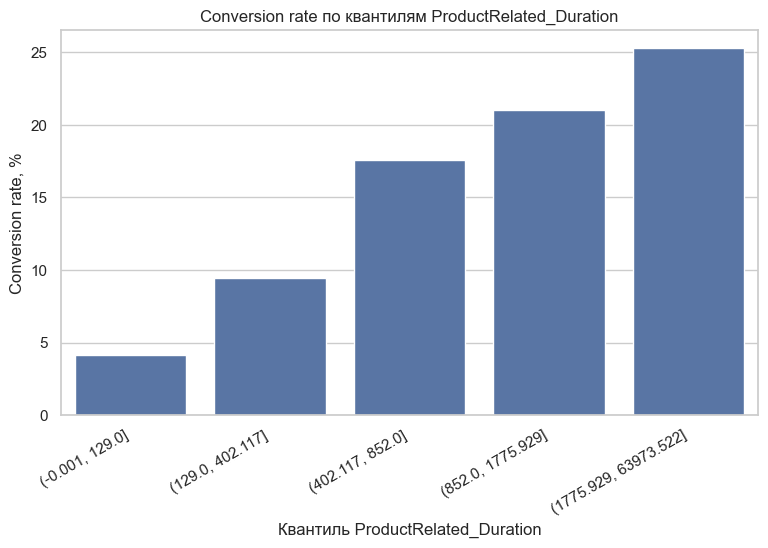

In [39]:
# ГИПОТЕЗА 1
q_table = conversion_by_quantile(df, 'ProductRelated_Duration')

plt.figure(figsize=(9, 5))
sns.barplot(x=q_table.index.astype(str), y=q_table['conversion_rate_%'], errorbar=None)
plt.xticks(rotation=30, ha='right')
plt.xlabel('Квантиль ProductRelated_Duration')
plt.ylabel('Conversion rate, %')
plt.title('Conversion rate по квантилям ProductRelated_Duration')
plt.show()

### Непараметрическая проверка

Сильно скошенные распределения делают Mann–Whitney U удобным базовым тестом различий между двумя группами. Он проверяет различие распределений, а не «прямую причинную зависимость».

In [33]:
buyers = df.loc[df['Revenue'], 'ProductRelated_Duration']
non_buyers = df.loc[~df['Revenue'], 'ProductRelated_Duration']

u_stat, p_value = mannwhitneyu(buyers, non_buyers, alternative='two-sided')

print(f'Mann–Whitney U = {u_stat:,.0f}')
print(f'p-value = {p_value:.3e}')
print(f'Median, Revenue=False: {non_buyers.median():.1f}')
print(f'Median, Revenue=True:  {buyers.median():.1f}')

Mann–Whitney U = 13,382,713
p-value = 5.332e-128
Median, Revenue=False: 510.2
Median, Revenue=True:  1109.9


Корректный вывод для гипотезы 1: если p-value мала и conversion rate растёт по квантилям, данные поддерживают наличие статистически значимой связи между `ProductRelated_Duration` и `Revenue`. Формулировка «время действительно влияет на вероятность покупки» была бы слишком сильной для observational data.

## 8. Bivariate Analysis of Numeric Features

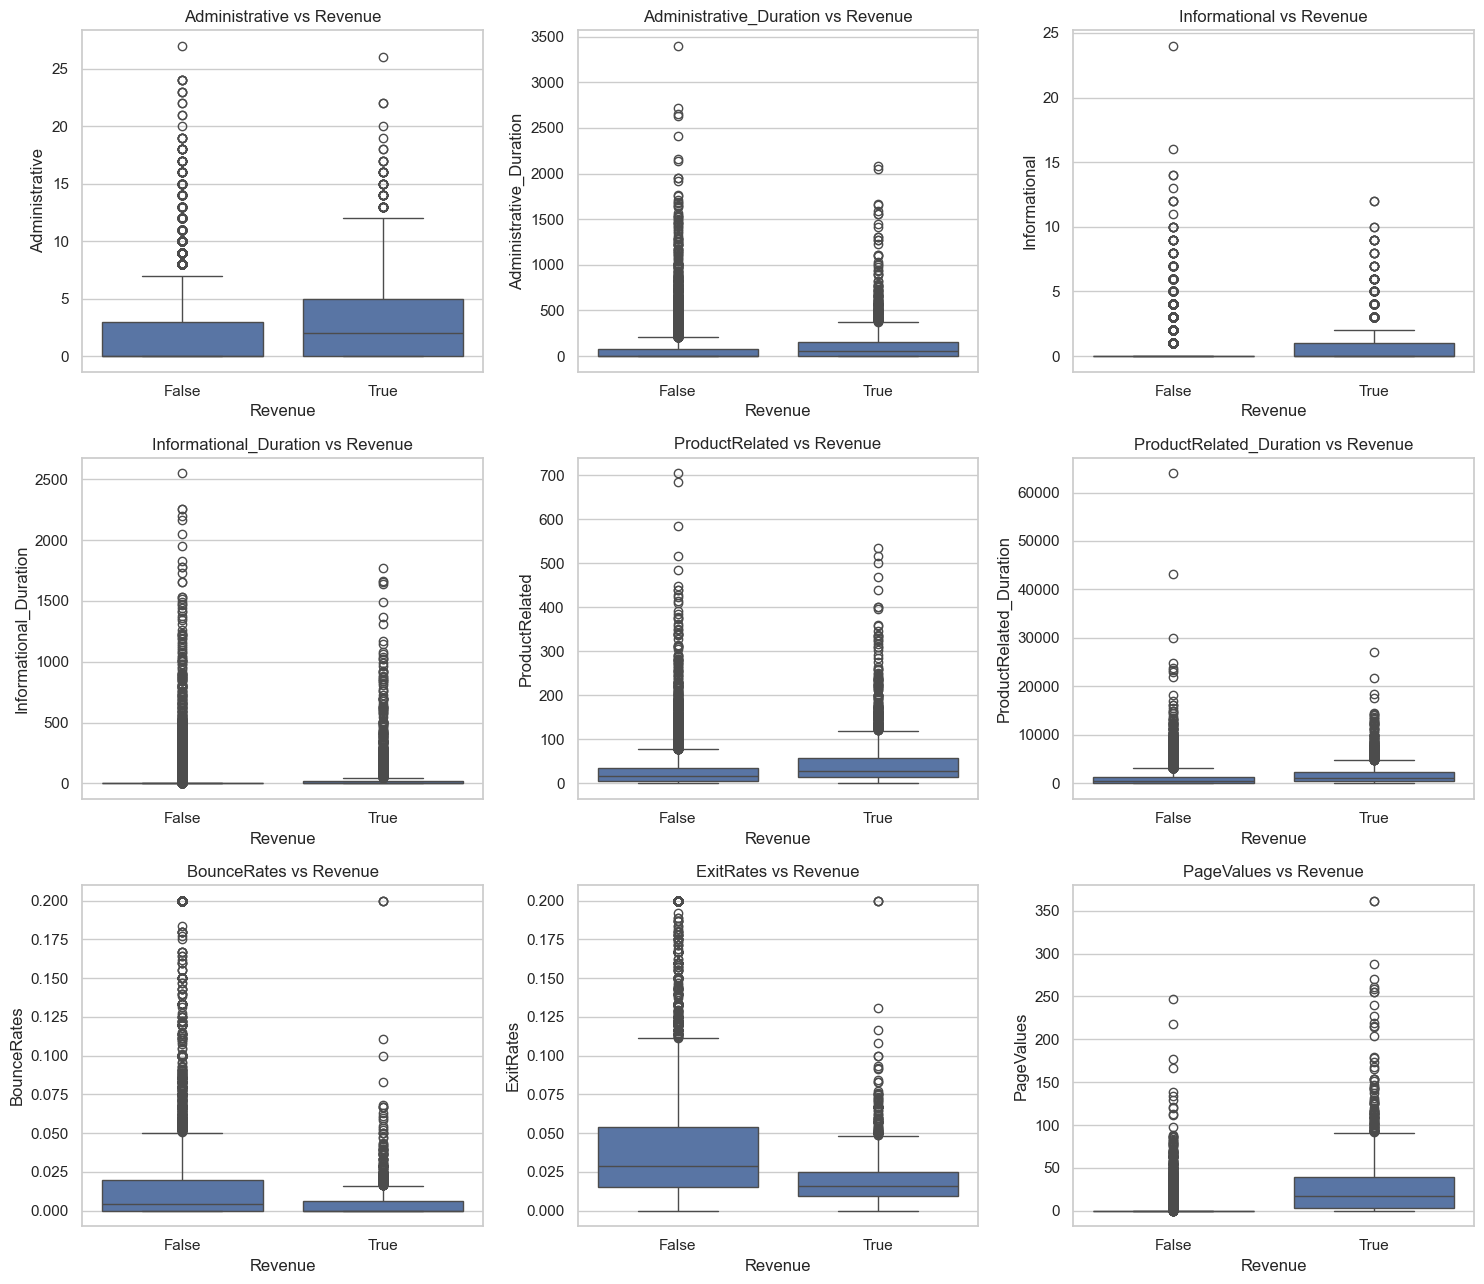

In [34]:
plot_features = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    sns.boxplot(x='Revenue', y=feature, data=df, ax=ax)
    ax.set_title(f'{feature} vs Revenue')
    ax.set_xlabel('Revenue')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

In [35]:
median_comparison = (
    df.groupby('Revenue')[
        ['Administrative', 'Administrative_Duration',
         'Informational', 'Informational_Duration',
         'ProductRelated', 'ProductRelated_Duration',
         'BounceRates', 'ExitRates', 'PageValues']
    ]
    .median()
    .T
)

display(median_comparison)

Revenue,False,True
Administrative,0.000,2.000
Administrative_Duration,0.000,52.367
Informational,0.000,0.000
Informational_Duration,0.000,0.000
ProductRelated,16.000,29.000
ProductRelated_Duration,510.190,"1,109.906"
BounceRates,0.004,0.000
ExitRates,0.029,0.016
PageValues,0.000,16.758


### Ключевые наблюдения

- `ProductRelated` и `ProductRelated_Duration` заметно различаются между классами; количественную связь лучше оценивать через квантильный анализ выше.
- `PageValues` особенно информативен из-за большого различия в распределениях и высокой доли нулей. Это сильный кандидат на отдельный univariate baseline в ML.
- `Informational` и `Informational_Duration` также показывают различия между классами, но точную полезность признаков оценим только после обучения моделей.
- `BounceRates` и `ExitRates` имеют сложную интерпретацию и высокую корреляцию; поэтому решение убрать `BounceRates` — верный выбор для baseline.

## 9. Train/Test Split Before Target-Guided Preprocessing

Сам EDA выше носит описательный характер. Но как только решение зависит от `Revenue` и будет использовано для обучения модели, его нужно принимать только по train.

Поэтому сейчас делим данные, а уже затем:
- группируем редкие категории;
- подбираем параметры preprocessing;
- fit-им scaler/encoder.

In [36]:
X = df_processed.drop(columns=['Revenue'])
y = df_processed['Revenue'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train:', X_train.shape, y_train.shape)
print('Test: ', X_test.shape, y_test.shape)
print('\nTrain target share:')
display(y_train.value_counts(normalize=True).sort_index().rename('share'))
print('\nTest target share:')
display(y_test.value_counts(normalize=True).sort_index().rename('share'))

Train: (9864, 18) (9864,)
Test:  (2466, 18) (2466,)

Train target share:


Revenue
0   0.845
1   0.155
Name: share, dtype: float64


Test target share:


Revenue
0   0.845
1   0.155
Name: share, dtype: float64

## 10. Rare Category Grouping — Train Only

In [37]:
features_to_group = ['Browser', 'OperatingSystems', 'TrafficType']
RARE_CATEGORY_THRESHOLD = 0.02

X_train_model = X_train.copy()
X_test_model = X_test.copy()

for col in features_to_group:
    train_freq = X_train_model[col].value_counts(normalize=True)
    frequent_categories = train_freq[train_freq >= RARE_CATEGORY_THRESHOLD].index

    X_train_model[col] = X_train_model[col].where(
        X_train_model[col].isin(frequent_categories), 'Other'
    )
    X_test_model[col] = X_test_model[col].where(
        X_test_model[col].isin(frequent_categories), 'Other'
    )

for col in ['Weekend']:
    X_train_model[col] = X_train_model[col].astype(str)
    X_test_model[col] = X_test_model[col].astype(str)

print('Частоты после grouping — Train:')
for col in features_to_group:
    print(f'\n{col}')
    display(X_train_model[col].value_counts(normalize=True).mul(100).rename('share_%').to_frame())

Частоты после grouping — Train:

Browser


,share_%
Browser,
2,64.487
1,19.860
4,6.042
Other,5.738
5,3.873



OperatingSystems


,share_%
OperatingSystems,
2,53.477
1,20.914
3,20.783
4,3.883
Other,0.943



TrafficType


,share_%
TrafficType,
2,31.782
1,19.607
3,16.768
4,8.779
13,5.890
Other,4.978
10,3.751
6,3.548
8,2.717


Важно: редкие категории определяются по train. Если категория редкая только в test, мы не используем эту информацию для построения правил preprocessing.

## 11. Model-Ready Preprocessing

Для baseline оставляем оба `ProductRelated*` признака и `Avg_Product_Duration`, но исключаем `BounceRates` как заранее выбранный дублирующий признак.

`RobustScaler` удобен для числовых данных со значимыми выбросами. `OneHotEncoder(handle_unknown='ignore')` позволяет безопасно встретить ранее не виденную категорию в test.

In [38]:
DROP_FOR_BASELINE = ['BounceRates']

categorical_cols = [
    'Month',
    'VisitorType',
    'Weekend',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

continuous_cols = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'Avg_Product_Duration'
]

X_train_model = X_train_model.drop(columns=DROP_FOR_BASELINE)
X_test_model = X_test_model.drop(columns=DROP_FOR_BASELINE)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), continuous_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols)
    ],
    remainder='drop'
)

X_train_prep = preprocessor.fit_transform(X_train_model)
X_test_prep = preprocessor.transform(X_test_model)

print('Prepared train shape:', X_train_prep.shape)
print('Prepared test shape: ', X_test_prep.shape)

TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']

## 12. Optional Linear-Model Specification Without Strongly Correlated Product Features

Для Logistic Regression полезно сравнить baseline выше с более простой спецификацией. Здесь мы убираем исходные `ProductRelated` и `ProductRelated_Duration`, оставляя `Avg_Product_Duration`.

Это не означает, что одна спецификация «правильная». Сравнение на кросс-валидации покажет, какая лучше обобщается.

In [ ]:
linear_drop = ['BounceRates', 'ProductRelated', 'ProductRelated_Duration']

X_train_linear = X_train.copy().drop(columns=linear_drop)
X_test_linear = X_test.copy().drop(columns=linear_drop)

for col in features_to_group:
    train_freq = X_train[col].value_counts(normalize=True)
    frequent_categories = train_freq[train_freq >= RARE_CATEGORY_THRESHOLD].index
    X_train_linear[col] = X_train_linear[col].where(X_train_linear[col].isin(frequent_categories), 'Other')
    X_test_linear[col] = X_test_linear[col].where(X_test_linear[col].isin(frequent_categories), 'Other')

X_train_linear['Weekend'] = X_train_linear['Weekend'].astype(str)
X_test_linear['Weekend'] = X_test_linear['Weekend'].astype(str)

linear_num = [c for c in continuous_cols if c not in ['ProductRelated', 'ProductRelated_Duration']]

linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), linear_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols)
    ],
    remainder='drop'
)

X_train_linear_prep = linear_preprocessor.fit_transform(X_train_linear)
X_test_linear_prep = linear_preprocessor.transform(X_test_linear)

print('Linear-spec train shape:', X_train_linear_prep.shape)
print('Linear-spec test shape: ', X_test_linear_prep.shape)

## 13. EDA Conclusions

### Что подтверждается уже на уровне EDA

1. Датасет несбалансирован по `Revenue`, поэтому accuracy нельзя использовать как единственную метрику.
2. Числовые поведенческие признаки имеют сильную правую асимметрию и выбросы.
3. `ProductRelated_Duration` и `ProductRelated` сильно связаны; при этом они несут разные аспекты поведения.
4. `PageValues` имеет большую массу нулей и заметно различается между классами — это сильный кандидат для отдельного ML-baseline.
5. `Browser`, `OperatingSystems` и `TrafficType` имеют много редких категорий; объединение редких значений в `Other` разумно как проверяемый preprocessing-приём.

### Еще не доказано / Требует подтверждения

- что более длительное пребывание вызывает покупку;
- что Decision Tree обязательно лучше Logistic Regression;
- что `PageValues` один даст почти всё качество полной модели;
- что `class_weight='balanced'` обязательно сильно повысит Recall и сильно снизит Precision.

Эти утверждения должны быть проверены в ML-экспериментах с одинаковым train/test split и корректной валидацией.